# [LAB-07] 12. 교차분석 - 연습문제

## 🎬 임금과 일터의 비밀

당신은 노동연구소에 갓 입사한 **신입 데이터 분석가**입니다.
출근 첫 주, 팀장님이 **미국 Mid-Atlantic 지역 남성 근로자 3,000명**의 임금 실태조사 파일(`wage`)을 건네며 말합니다.

> "올해 보고서 주제는 **'어떤 사람이, 어떤 일터에서, 어떤 보호를 받고 일하는가'** 예요.
> 숫자(임금)는 회귀팀이 맡고, **당신은 '범주와 범주 사이의 관계'**를 책임지세요.
> 교차표를 만들고 카이제곱 검정을 돌려서, **결론을 한 단어로** 가져오세요."

아래 6개의 미션을 **스스로 코드를 작성**해 해결하고, 각 문제의 답을 **한 단어**로 도출하세요.

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import my_stats          # 교차분석 모듈 (적합도/독립성/동질성)
import pandas as pd
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 불러오기

In [2]:
origin = load_data("wage")
origin.head()

📚 경제 및 노동 시장에 관련된 정보를 담고 있는 데이터셋(출처: ADsP 기출문제)

    field       description
--  ----------  ------------------
 0  year        년도
 1  age         나이
 2  maritl      결혼여부
 3  race        근로자의 인종
 4  education   교육수준
 5  region      지역
 6  jobclass    직군
 7  health      건상상태
 8  health_ins  건강보험 가입 여부
 9  logwage     임금(로그값)
10  wage        임금



,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318,75.043
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255,70.476
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875,130.982
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041,154.685
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318,75.043


### 3. 데이터 전처리

라벨 앞의 번호(`1. `, `2. ` …)를 떼어내 결과 표를 보기 좋게 정리해 둡니다. *(선택사항)*

In [3]:
df = origin.copy()
for c in ['maritl', 'race', 'education', 'region', 'jobclass', 'health', 'health_ins']:
    df[c] = df[c].str.replace(r'^\d+\.\s*', '', regex=True)

df.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,Never Married,White,< HS Grad,Middle Atlantic,Industrial,<=Good,No,4.318,75.043
1,2004,24,Never Married,White,College Grad,Middle Atlantic,Information,>=Very Good,No,4.255,70.476
2,2003,45,Married,White,Some College,Middle Atlantic,Industrial,<=Good,Yes,4.875,130.982
3,2003,43,Married,Asian,College Grad,Middle Atlantic,Information,>=Very Good,Yes,5.041,154.685
4,2005,50,Divorced,White,HS Grad,Middle Atlantic,Information,<=Good,Yes,4.318,75.043


## [미션 1] "절반씩 일하나요?" — 적합도 검정

팀장님이 묻습니다. "우리 표본의 근로자가 **Industrial 직군과 Information 직군에 정확히 절반씩(50:50)** 나뉘어 있다고 봐도 될까요?"

유의수준 5%에서, "두 직군이 균등하게 분포한다"는 **귀무가설**에 대한 판정은? *(채택 / 기각)*

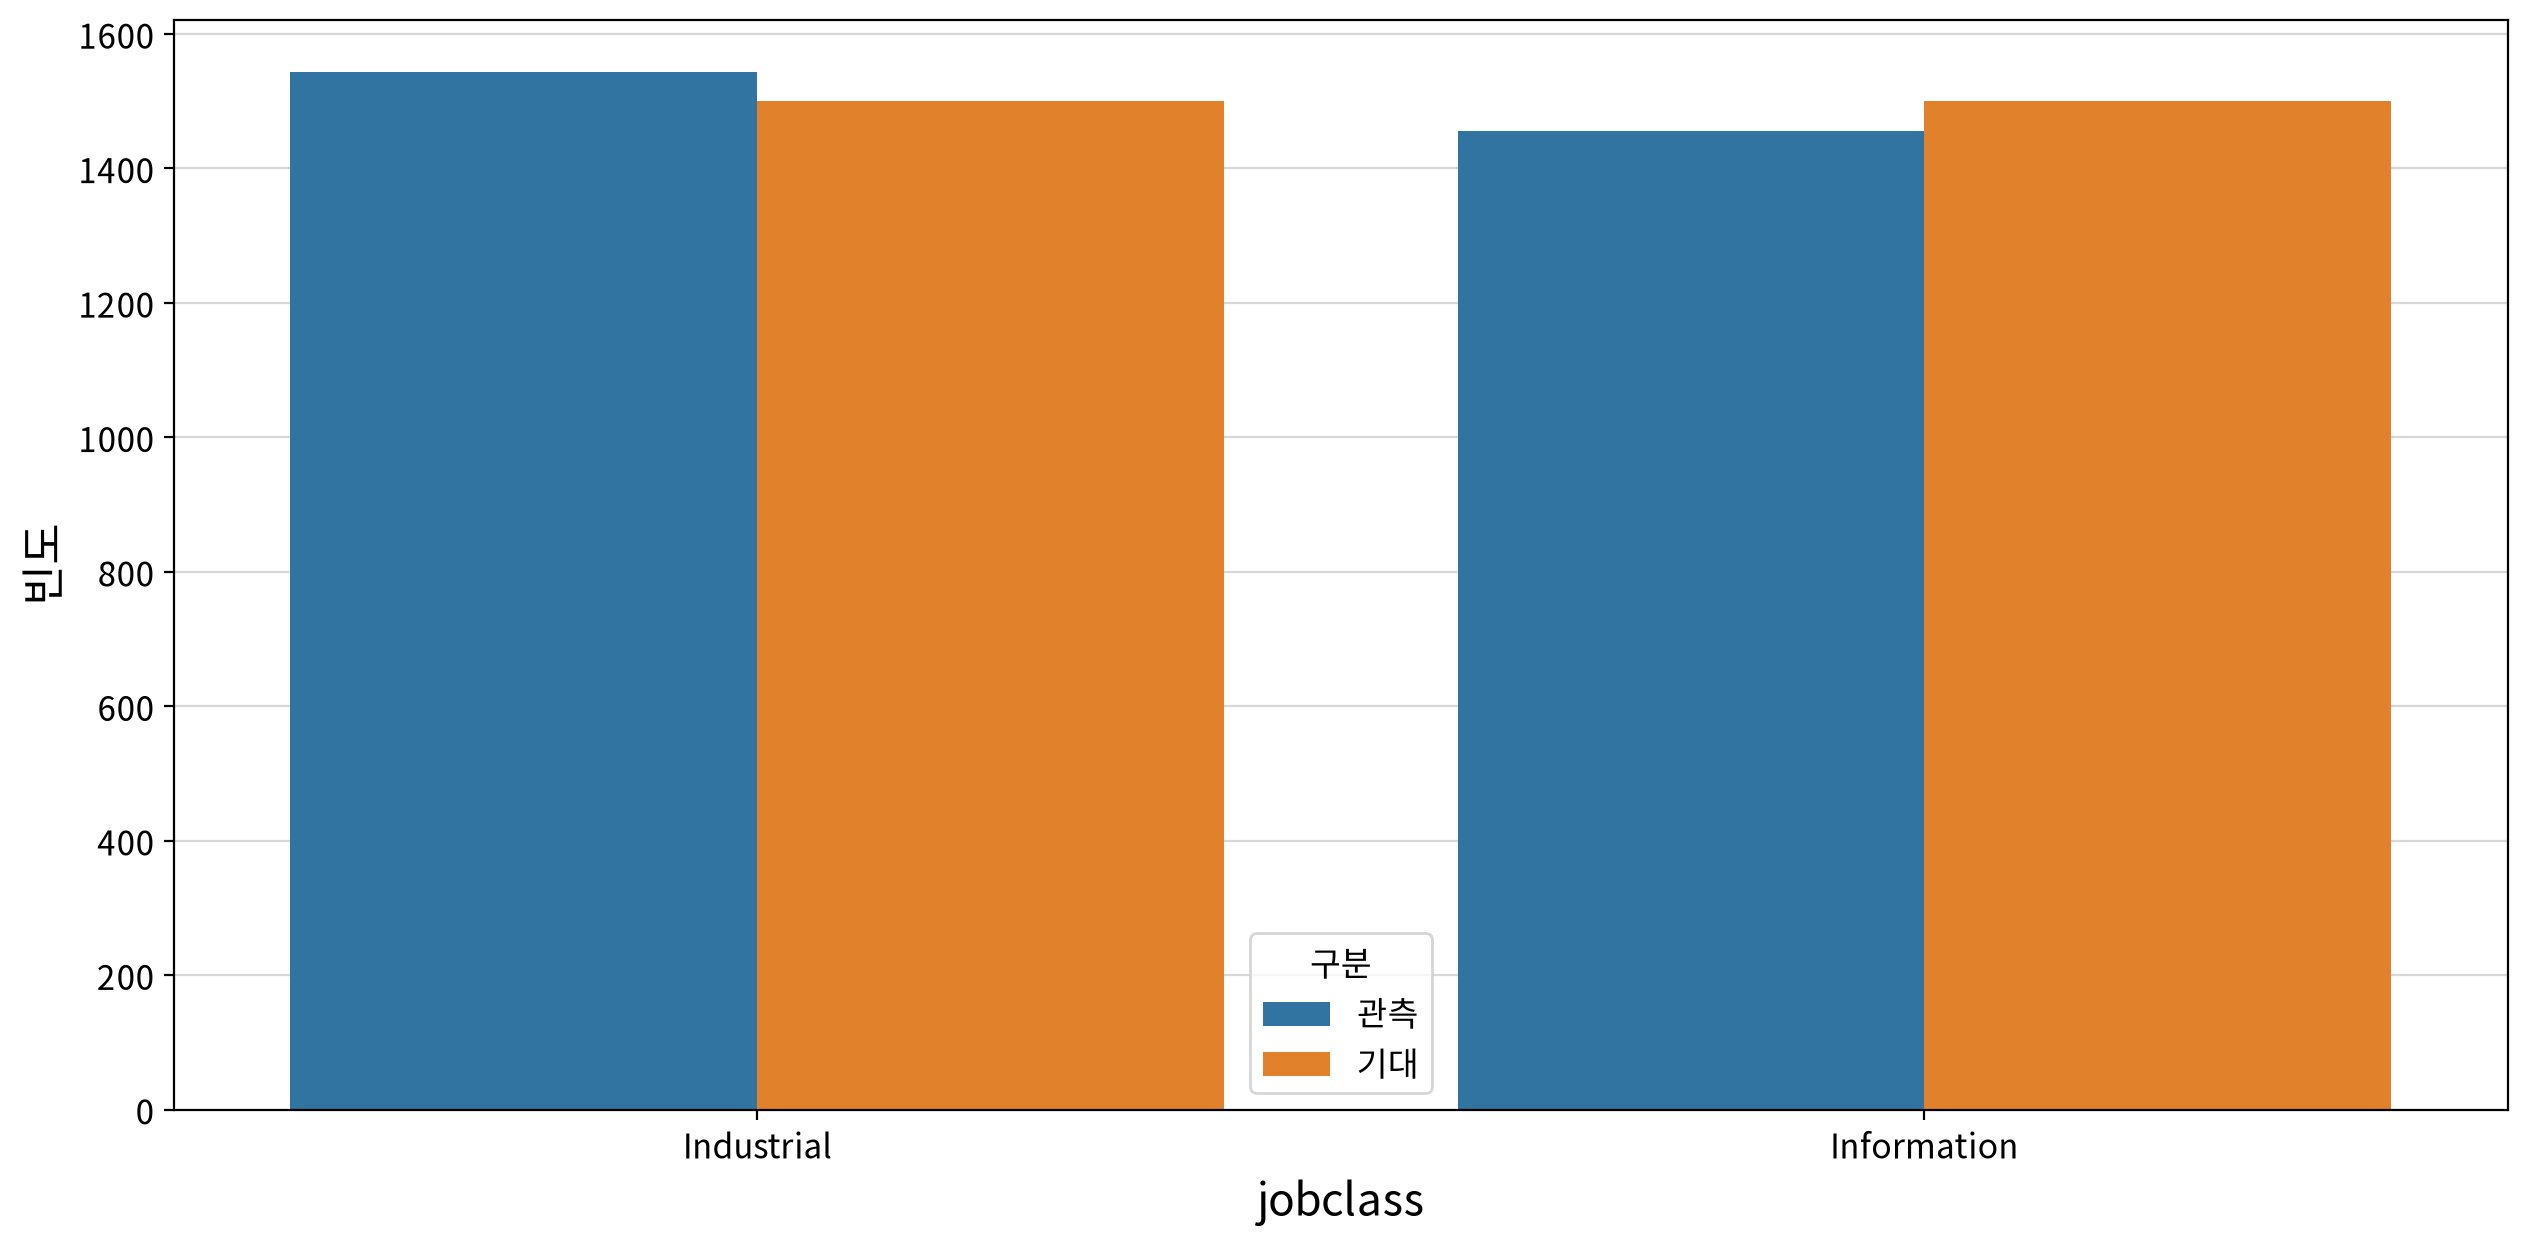

,chi2,dof,p-value,significant,effect(w),strength,min_expected,assumption
Chi-square goodness-of-fit,2.581,1,0.108,False,0.029,Negligible,1500.000,True


In [4]:
# 적합도 검정: 기대분포 기본값이 '균등(50:50)' 이므로 expected 생략
# 결과표의 significant 컬럼을 확인 → False면 채택, True면 기각
my_stats.chi2_goodness_of_fit(df, 'jobclass')

### 정답 ① : **채택**

`jobclass` 변수로 **적합도 검정(goodness-of-fit)** 을 수행하세요.

**해설** — Industrial 1,544명 vs Information 1,456명. χ²≈2.58, **p≈0.108 > 0.05** → 결과표의 `significant`가 **False**.
"50:50으로 균등하다"는 귀무가설을 **기각하지 못합니다(채택)**. 두 직군의 인원수 차이는 우연 수준입니다.
(`effect(w)`≈0.03 으로 효과크기도 'Negligible' — 차이가 거의 없음을 함께 확인.)

## [미션 2] "배움이 일터를 바꾸나요?" — 독립성 검정 ①

"교육을 더 받은 사람일수록 사무·정보(Information) 직군에서 일할까요, 아니면 **교육수준과 직군은 서로 무관**할까요?"

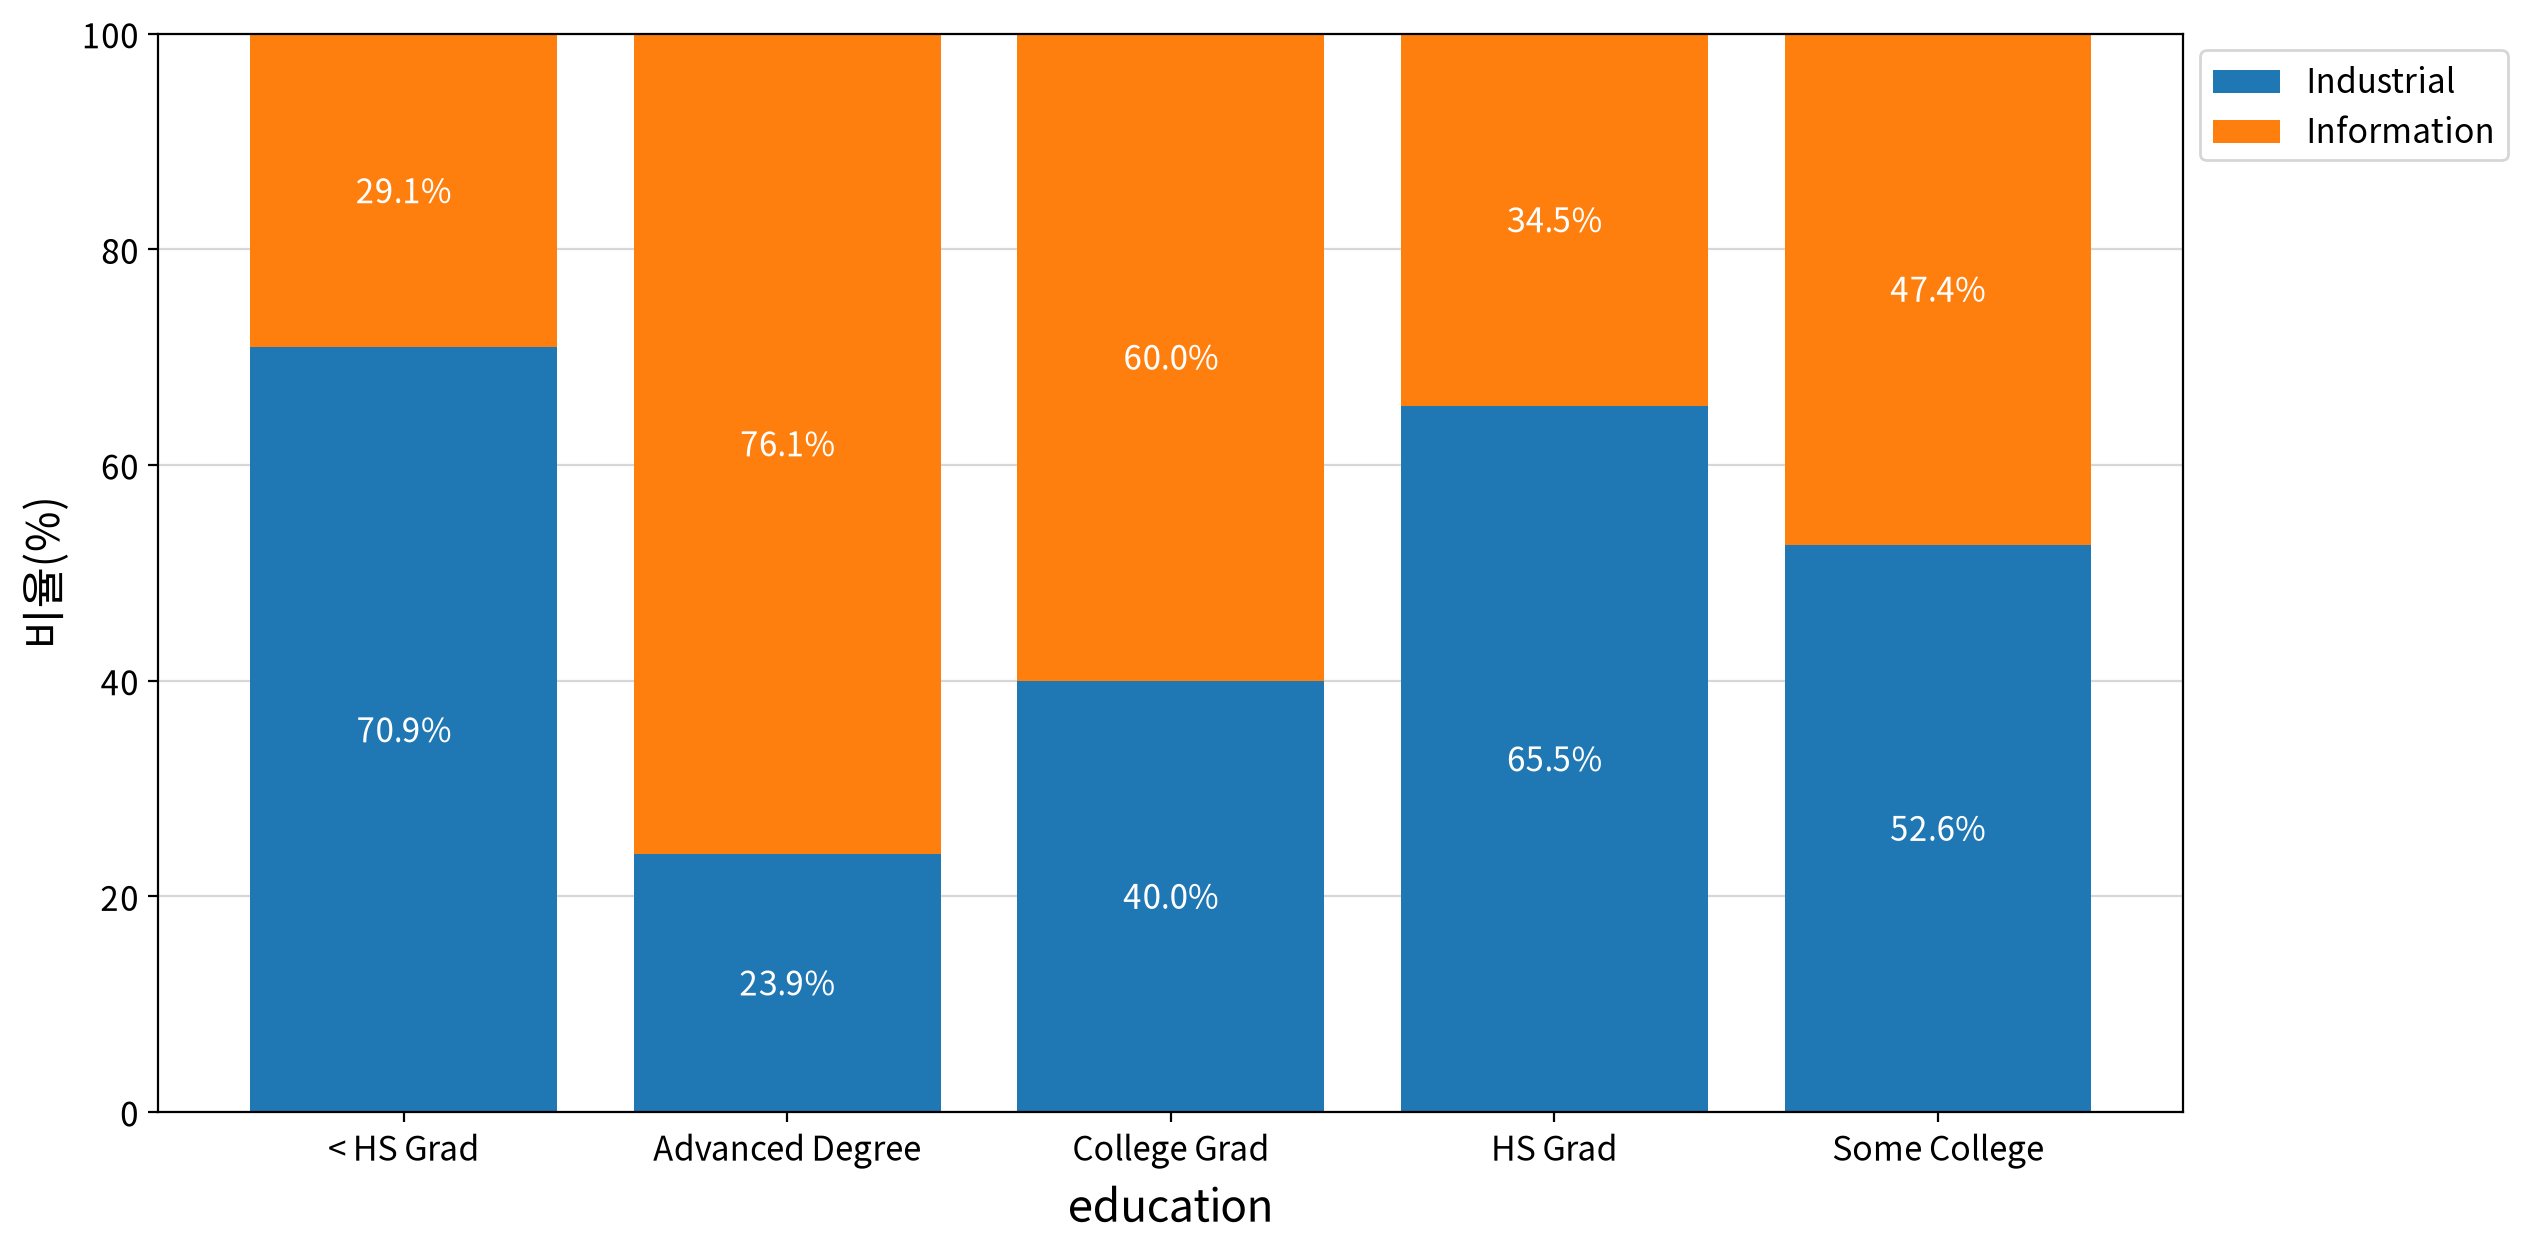

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
education,jobclass,Chi-square test of independence,282.643,4,0.000,True,0.307,Moderate,130.070,True


In [5]:
# 독립성 검정 (100% 누적 막대그래프로 교육수준별 직군 구성비도 함께 시각화)
# 어느 교육수준에서 Information 비율이 가장 높은지 행 기준 비율로 확인
my_stats.chi2_independence(df, 'education', 'jobclass')

### 정답 ②-1 : **기각**  /  ②-2 : **Advanced Degree**

`education` × `jobclass` 로 **독립성 검정**을 수행하세요.

**해설** — χ²≈282.6, **p≈0 (≪0.05)** → `significant=True` 이므로 "교육수준과 직군은 독립"이라는 귀무가설을 **기각**합니다.
효과크기 `effect(V)`≈0.31 ('Moderate'). 누적 막대그래프·행 비율을 보면 **Advanced Degree(고급학위)**의 76.1%가 Information 직군으로 가장 높습니다. → **배움이 일터를 바꾼다.**

## [미션 3] "누가 사각지대에 있나요?" — 독립성 검정 ②

복지팀의 긴급 요청: "건강보험 **미가입자**를 줄이는 캠페인을 하려는데, **가장 우선 지원해야 할 교육수준 집단**을 콕 집어주세요."

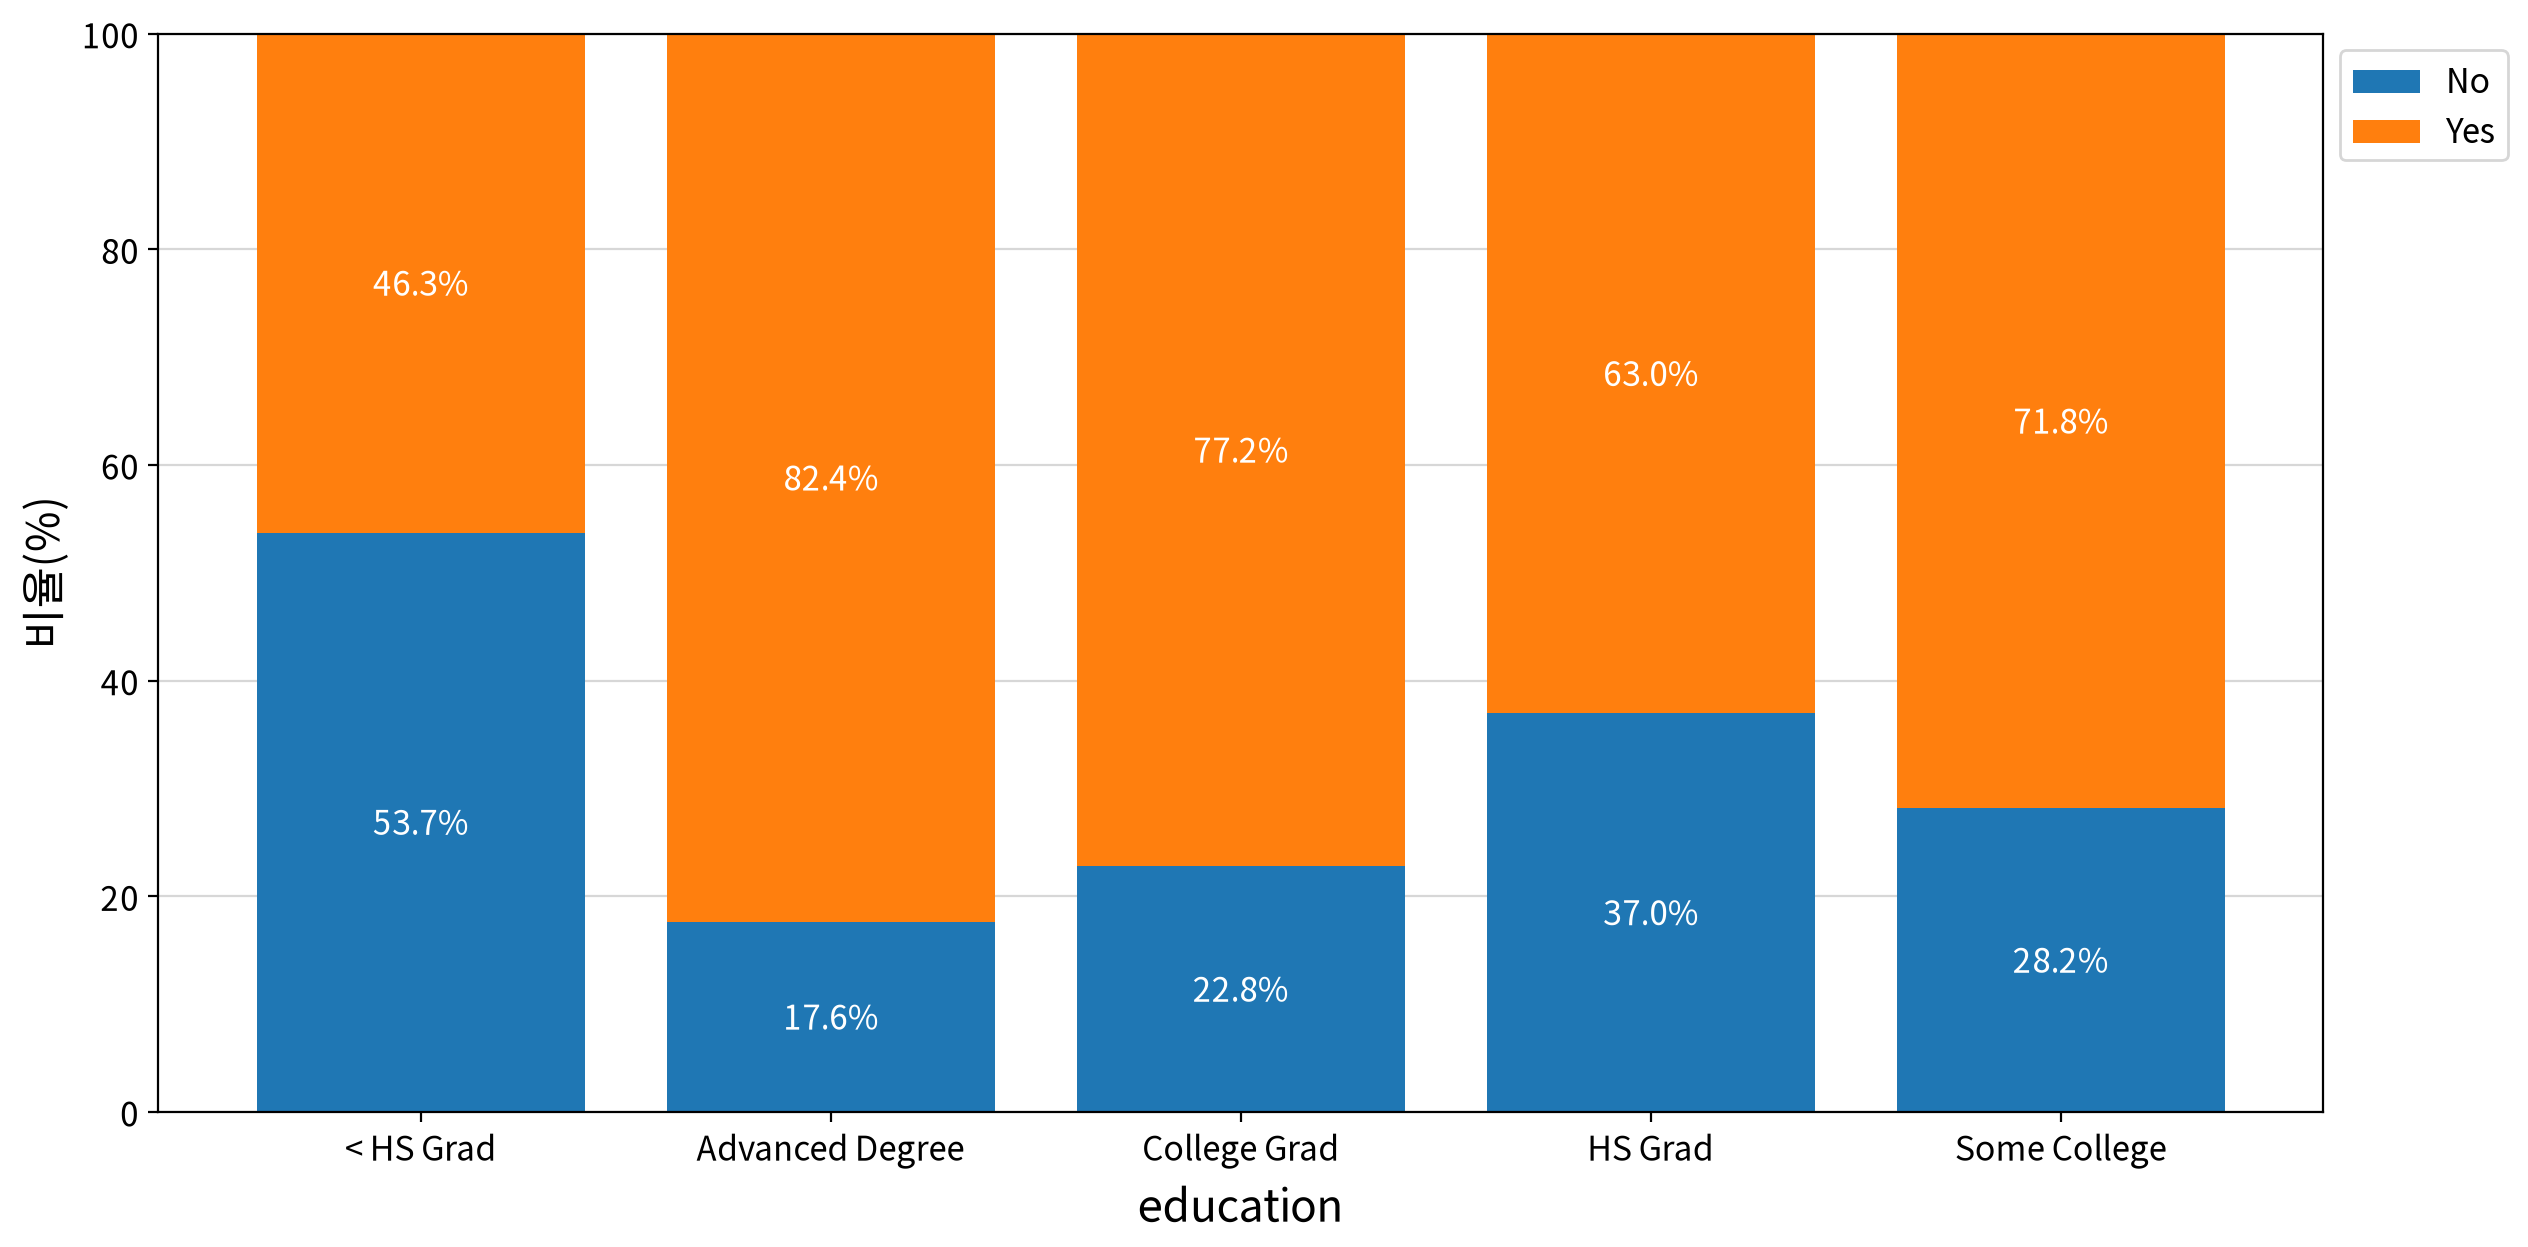

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
education,health_ins,Chi-square test of independence,141.635,4,0.000,True,0.217,Weak,81.920,True


In [6]:
my_stats.chi2_independence(df, 'education', 'health_ins')

### 정답 ③ : **< HS Grad** (고졸 미만)

`education` × `health_ins` 교차표에서 **'No'(미가입) 비율이 가장 높은** 교육수준 집단을 찾으세요.

**해설** — χ²≈141.6, p≈0 → `significant=True`. 교육수준과 보험가입은 유의하게 연관됩니다.
**< HS Grad** 집단의 **미가입률이 53.7%**로 가장 높아 캠페인 1순위 타깃입니다. 학력이 높을수록 가입률이 올라가 Advanced Degree는 82.4%가 가입되어 있습니다.

## [미션 4] "어떤 일터가 더 안전망이 두텁나요?" — 동질성 검정

"Industrial 직군과 Information 직군, **두 집단의 건강보험 가입 분포가 같은지** 비교해 주세요. 다르다면 어느 쪽 가입률이 높죠?"

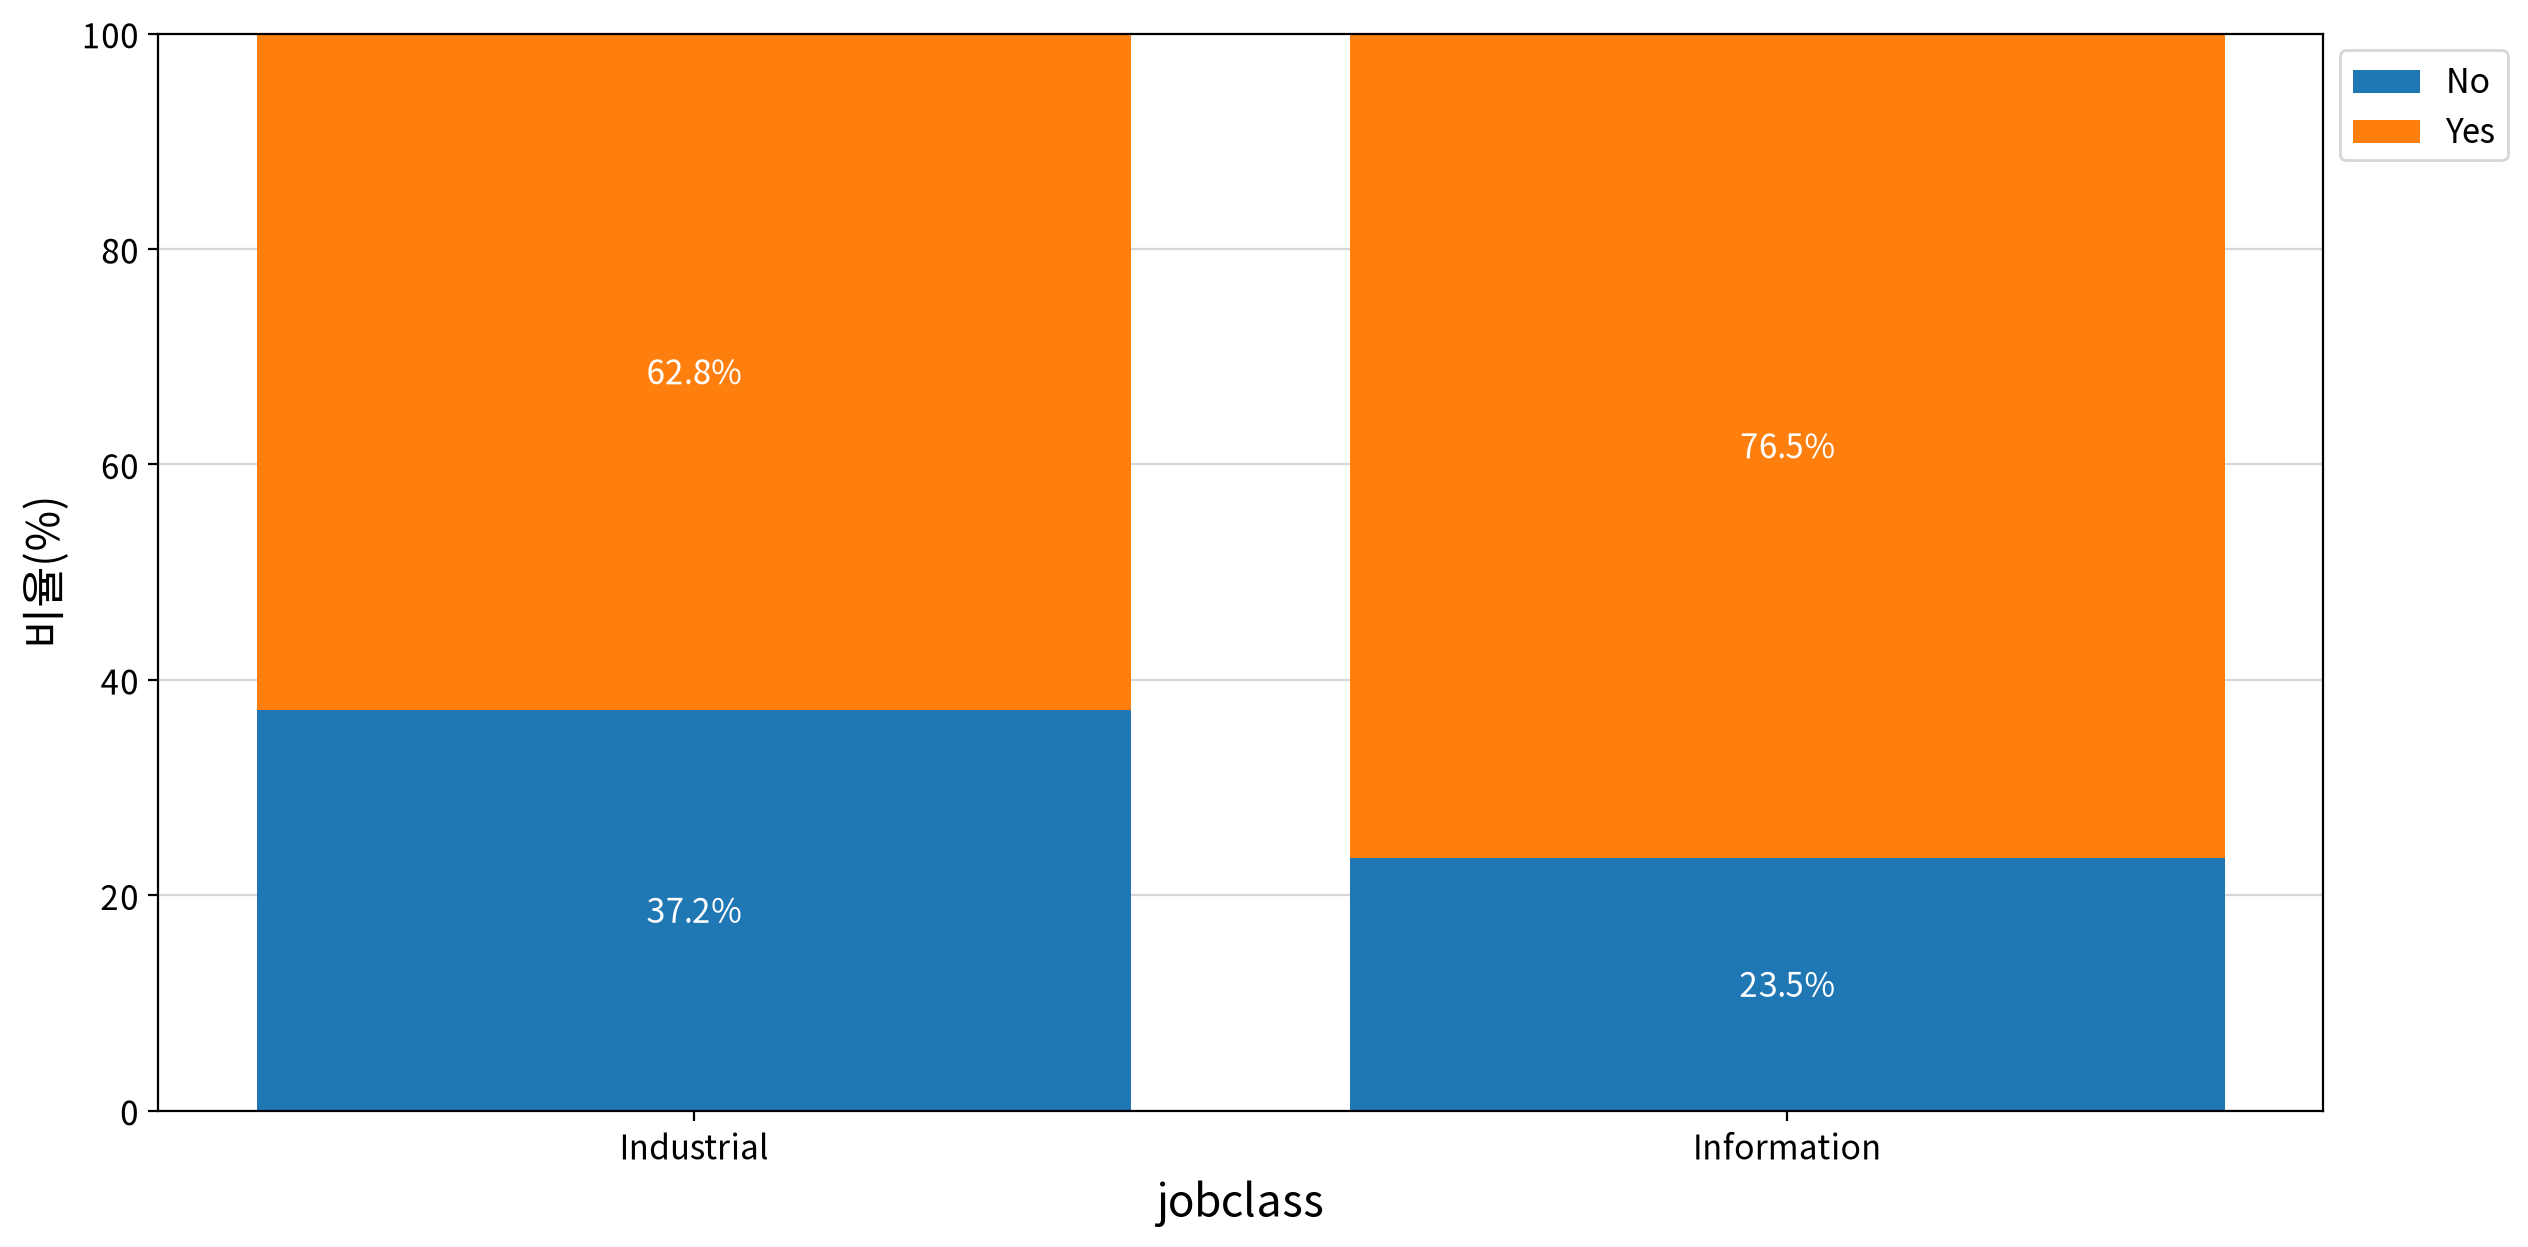

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
jobclass,health_ins,Chi-square test of homogeneity,66.126,1,0.000,True,0.148,Weak,445.050,True


In [7]:
# 동질성 검정: 두 직군(집단)의 보험가입 분포가 동질한가?
my_stats.chi2_homogeneity(df, 'jobclass', 'health_ins')

### 정답 ④-1 : **기각**  /  ④-2 : **Information**

`jobclass` × `health_ins` 로 **동질성 검정**을 수행하세요.

**해설** — χ²≈66.1, p≈0 → `significant=True` 이므로 두 직군의 보험가입 분포가 "동질하다"는 귀무가설을 **기각**합니다.
**Information 직군의 가입률 76.5%** > Industrial 62.8% 로, 사무·정보 직군의 사회안전망이 더 두텁습니다.

> 💡 **독립성 vs 동질성**: 계산은 동일(`chi2_independence`와 `chi2_homogeneity`는 내부적으로 같은 로직)하지만, *한 모집단에서 두 변수를 동시에 관측*하면 독립성, *서로 다른 집단(직군)의 분포를 비교*하면 동질성으로 해석합니다.

## [미션 5] "가장 강한 끈은?" — 효과크기(Cramér's V) 비교

"유의하다고 다 같은 게 아니에요. **임금(상위 25%를 '고임금'으로 구분)** 과 가장 **강하게** 연결된 범주형 변수가 뭔지 **Cramér's V**로 비교해 보세요. `education`, `jobclass`, `health` 중에서요."

In [8]:
# 임금 상위 25%를 '고임금'으로 이진화
df['고임금'] = np.where(df['wage'] >= df['wage'].quantile(0.75), '고임금', '일반')
df.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage,고임금
0,2006,18,Never Married,White,< HS Grad,Middle Atlantic,Industrial,<=Good,No,4.318,75.043,일반
1,2004,24,Never Married,White,College Grad,Middle Atlantic,Information,>=Very Good,No,4.255,70.476,일반
2,2003,45,Married,White,Some College,Middle Atlantic,Industrial,<=Good,Yes,4.875,130.982,고임금
3,2003,43,Married,Asian,College Grad,Middle Atlantic,Information,>=Very Good,Yes,5.041,154.685,고임금
4,2005,50,Divorced,White,HS Grad,Middle Atlantic,Information,<=Good,Yes,4.318,75.043,일반


In [9]:
my_stats.chi2_independence(df, 'education', '고임금', plot=False)

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
education,고임금,Chi-square test of independence,567.564,4,0.000,True,0.435,Moderate,69.230,True


In [10]:
my_stats.chi2_independence(df, 'jobclass', '고임금', plot=False)

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
jobclass,고임금,Chi-square test of independence,63.346,1,0.000,True,0.145,Weak,376.130,True


In [11]:
my_stats.chi2_independence(df, 'health', '고임금', plot=False)

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
health,고임금,Chi-square test of independence,49.404,1,0.000,True,0.128,Weak,221.650,True


### 정답 ⑤ : **education**

**해설** — 세 변수 모두 고임금 여부와 유의하게 연관되지만 **효과크기**는 다릅니다.
`education` V≈**0.435**('Moderate') ≫ `jobclass`≈0.15 > `health`≈0.13('Weak'). **교육수준이 임금과 가장 강하게 연결**됩니다.
p값은 관계의 '유무'만, `effect(V)`는 '세기'를 알려준다는 점이 핵심입니다.